# PHPP Operational Analytics

### Vessel Activity, Catch Accuracy, Economic Scale, and Fisheries Segmentation  
**Real-world operational data — PT. Daya Bahari Nusantara**

This notebook is the main analytical workflow for the practical-work project using manually collected **Post-Production Fisheries Levy (Pungutan Hasil Perikanan Pascaproduksi / PHPP)** records.

The source records were compiled from company operational documents and prepared in the preceding preprocessing notebook. The analysis is structured at two different levels:

1. **Vessel-trip level** — one record represents one operational trip / levy record after aggregating fish-species rows.
2. **Species-record level** — one record represents a fish species recorded within an operational trip.

### Analytical objectives

- Profile fleet and operational activity across companies, vessels, fishing gear, and time.
- Examine the relationship between captain-estimated catch and recorded actual catch.
- Explore production value and fisheries-levy patterns.
- Identify dominant fish species and catch-volume patterns.
- Segment vessel trips and species records using K-Means clustering.

> **Methodological note:** Encoded company, vessel, fish-species, and fishing-gear IDs are treated as categorical identifiers rather than ordinal numeric measurements. They are therefore excluded from numeric correlation and regression calculations.


## 1. Environment Setup


In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Load the Preprocessed Dataset

The input file is produced by `01_data_preprocessing.ipynb`.  
Dates are parsed again after CSV loading because CSV files do not preserve pandas `datetime` dtypes.


In [ ]:
DATA_PATH = "data/dataphpp2.csv"

df = pd.read_csv(DATA_PATH)

date_columns = ["Tanggal Keberangkatan", "Tanggal Kedatangan"]
for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 777 rows × 12 columns


,Nama Perusahaan,Nama Kapal,Ukuran Kapal (GT),Tanggal Keberangkatan,Tanggal Kedatangan,Alat Penangkapan Ikan,Jenis Ikan,Estimasi Nakhoda (kg),Volume Ril (kg),Harga Acuan Ikan per Kg (Rp),Nilai Produksi (Rp),Besar Pungutan Hasil Perikanan
0,5,24,133,2024-01-06,2024-11-20,1,3,41250,41679,9500,395950500,46951100
1,5,24,133,2024-01-06,2024-11-20,1,9,295,500,9500,4750000,46951100
2,5,24,133,2024-01-06,2024-11-20,1,10,97,97,17000,1649000,46951100
3,5,24,133,2024-01-06,2024-11-20,1,11,1980,2180,22000,47960000,46951100
4,5,24,133,2024-01-06,2024-11-20,1,18,1970,2259,8500,19201500,46951100


### 2.1 Dataset Profile and Quality Check

The project dataset contains **777 species-level observations** and **12 variables** in the original analytical notebook. Before analysis, the schema, missing values, uniqueness, and exact-row duplicates are reviewed.


In [ ]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(dropna=False)
})

display(profile)
print(f"Exact-row duplicates: {df.duplicated().sum()}")

,dtype,missing_values,unique_values
Nama Perusahaan,int64,0,12
Nama Kapal,int64,0,26
Ukuran Kapal (GT),int64,0,20
Tanggal Keberangkatan,datetime64[us],0,56
Tanggal Kedatangan,datetime64[us],0,61
Alat Penangkapan Ikan,int64,0,3
Jenis Ikan,int64,0,24
Estimasi Nakhoda (kg),int64,0,322
Volume Ril (kg),int64,0,641
Harga Acuan Ikan per Kg (Rp),int64,0,17


Exact-row duplicates: 0


## 3. Create the Two Analytical Grains

The raw analytical table contains multiple fish-species rows for the same vessel trip. Using that structure directly for vessel-level analysis would over-count trips.

Two dedicated tables are therefore created:

- `vessel_trip_df`: aggregates fish-species records into unique vessel-trip records.
- `species_df`: preserves the species-level grain for catch-composition analysis.


### 3.1 Vessel-Trip Dataset


In [ ]:
vessel_trip_df = (
    df.groupby([
        "Nama Perusahaan",
        "Nama Kapal",
        "Ukuran Kapal (GT)",
        "Tanggal Keberangkatan",
        "Tanggal Kedatangan",
        "Alat Penangkapan Ikan",
        "Besar Pungutan Hasil Perikanan"
    ])
    .agg({
        "Jenis Ikan": "nunique",
        "Estimasi Nakhoda (kg)": "sum",
        "Volume Ril (kg)": "sum",
        "Nilai Produksi (Rp)": "sum"
    })
    .reset_index()
    .rename(columns={
        "Jenis Ikan": "Jumlah Jenis Ikan",
        "Estimasi Nakhoda (kg)": "Total Estimasi Nakhoda (kg)",
        "Volume Ril (kg)": "Total Volume Ril (kg)",
        "Nilai Produksi (Rp)": "Total Nilai Produksi (Rp)"
    })
)

print(f"Vessel-trip records: {len(vessel_trip_df):,}")
vessel_trip_df.head()

Vessel-trip records: 133


,Nama Perusahaan,Nama Kapal,Ukuran Kapal (GT),Tanggal Keberangkatan,Tanggal Kedatangan,Alat Penangkapan Ikan,Besar Pungutan Hasil Perikanan,Jumlah Jenis Ikan,Total Estimasi Nakhoda (kg),Total Volume Ril (kg),Total Nilai Produksi (Rp)
0,0,22,70,2024-04-10,2024-10-15,2,1702600,3,714,688,17026000
1,0,22,70,2024-05-12,2024-12-16,2,676200,3,272,288,6762000
2,0,22,70,2024-09-27,2024-11-10,2,6627160,13,3056,2962,66271600
3,0,22,70,2024-10-18,2024-01-11,2,732600,2,345,333,7326000
4,0,22,70,2024-10-25,2024-06-11,2,1777400,3,793,740,17774000


### 3.2 Species-Level Dataset


In [ ]:
species_df = df[[
    "Jenis Ikan",
    "Estimasi Nakhoda (kg)",
    "Volume Ril (kg)",
    "Harga Acuan Ikan per Kg (Rp)",
    "Alat Penangkapan Ikan",
    "Nilai Produksi (Rp)"
]].copy()

print(f"Species-level records: {len(species_df):,}")
species_df.head()

Species-level records: 777


,Jenis Ikan,Estimasi Nakhoda (kg),Volume Ril (kg),Harga Acuan Ikan per Kg (Rp),Alat Penangkapan Ikan,Nilai Produksi (Rp)
0,3,41250,41679,9500,1,395950500
1,9,295,500,9500,1,4750000
2,10,97,97,17000,1,1649000
3,11,1980,2180,22000,1,47960000
4,18,1970,2259,8500,1,19201500


# Part A — Vessel-Trip Analysis


## 4. Vessel-Trip Overview

This section evaluates operational scale per trip, including vessel size, species diversity, estimated catch, actual catch, production value, and PHPP levy.


In [ ]:
vessel_numeric = [
    "Ukuran Kapal (GT)",
    "Besar Pungutan Hasil Perikanan",
    "Jumlah Jenis Ikan",
    "Total Estimasi Nakhoda (kg)",
    "Total Volume Ril (kg)",
    "Total Nilai Produksi (Rp)"
]

vessel_trip_df[vessel_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
Ukuran Kapal (GT),133.00,139.60,40.43,58.00,126.00,134.00,181.00,207.00
Besar Pungutan Hasil Perikanan,133.00,"42,964,191.69","34,776,274.57","177,400.00","20,742,000.00","36,172,650.00","55,282,000.00","182,097,850.00"
Jumlah Jenis Ikan,133.00,5.84,1.60,2.00,5.00,6.00,7.00,13.00
Total Estimasi Nakhoda (kg),133.00,"38,741.21","29,847.42",140.00,"19,000.00","34,700.00","52,200.00","133,800.00"
Total Volume Ril (kg),133.00,"41,584.19","33,749.36",143.00,"20,193.00","35,627.00","52,965.00","161,664.00"
Total Nilai Produksi (Rp),133.00,"430,560,911.28","346,729,362.09","3,548,000.00","207,420,000.00","361,726,500.00","552,820,000.00","1,820,978,500.00"


### 4.1 Distribution and Outlier Diagnostics

Operational fisheries data naturally contain large trips and high-value observations. These values are not removed automatically because an extreme value can represent a valid high-volume operation rather than a recording error.

The following diagnostic summarizes skewness and the number of observations flagged by the standard 1.5×IQR rule.


In [ ]:
def iqr_diagnostic(dataframe, columns):
    rows = []

    for column in columns:
        series = dataframe[column].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((series < lower) | (series > upper)).sum()

        rows.append({
            "variable": column,
            "skewness": skew(series),
            "kurtosis": kurtosis(series),
            "iqr_outliers": int(outlier_count)
        })

    return pd.DataFrame(rows)

vessel_distribution = iqr_diagnostic(vessel_trip_df, vessel_numeric)
vessel_distribution

,variable,skewness,kurtosis,iqr_outliers
0,Ukuran Kapal (GT),-0.33,-0.48,0
1,Besar Pungutan Hasil Perikanan,1.36,1.98,10
2,Jumlah Jenis Ikan,0.07,2.30,1
3,Total Estimasi Nakhoda (kg),0.96,0.64,6
4,Total Volume Ril (kg),1.25,1.43,11
5,Total Nilai Produksi (Rp),1.37,2.01,10


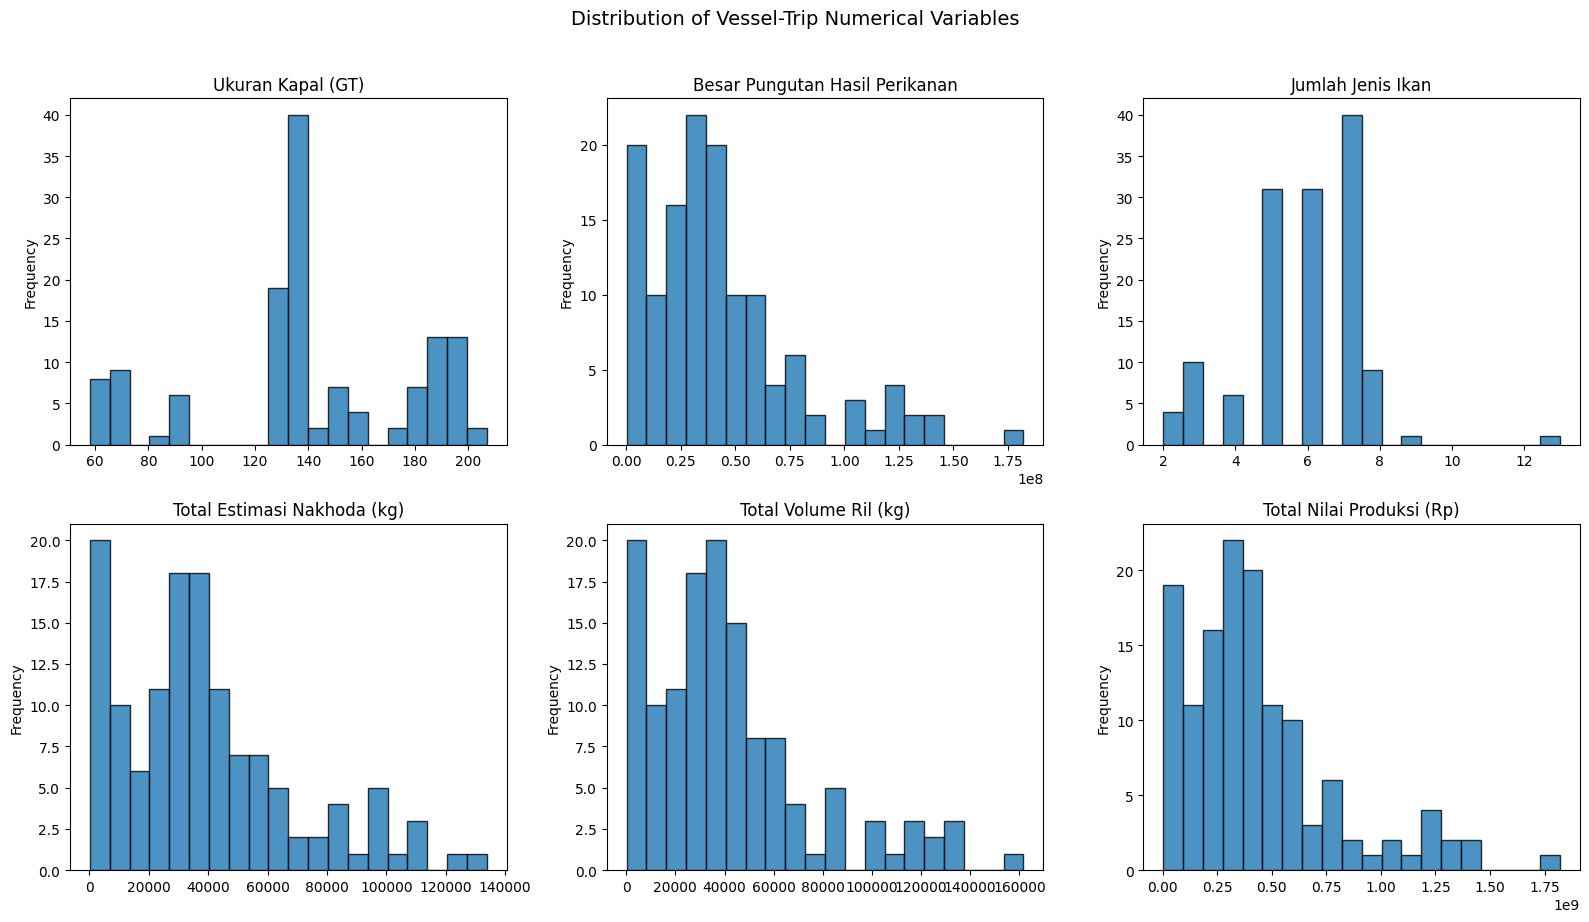

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, vessel_numeric):
    ax.hist(vessel_trip_df[column].dropna(), bins=20, edgecolor="black", alpha=0.8)
    ax.set_title(column)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Vessel-Trip Numerical Variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Fleet and Operational Activity

The fleet profile is examined through company activity, vessel activity, vessel size, and fishing-gear usage.

Because company and vessel fields are encoded identifiers, the analysis interprets their **frequency of operational records**, not their numerical code values.


### 5.1 Company Activity


In [ ]:
company_activity = (
    vessel_trip_df["Nama Perusahaan"]
    .value_counts()
    .rename_axis("Company ID")
    .reset_index(name="Trips")
)

company_activity["Share (%)"] = (
    company_activity["Trips"] / company_activity["Trips"].sum() * 100
)

top3_share = company_activity.head(3)["Trips"].sum() / company_activity["Trips"].sum() * 100

print(f"Number of companies: {len(company_activity)}")
print(f"Top 3 companies' share of vessel-trip records: {top3_share:.2f}%")
company_activity

Number of companies: 12
Top 3 companies' share of vessel-trip records: 62.41%


,Company ID,Trips,Share (%)
0,5,42,31.58
1,6,25,18.80
2,11,16,12.03
3,0,9,6.77
4,8,9,6.77
5,9,8,6.02
6,10,8,6.02
7,7,5,3.76
8,3,4,3.01
9,1,3,2.26


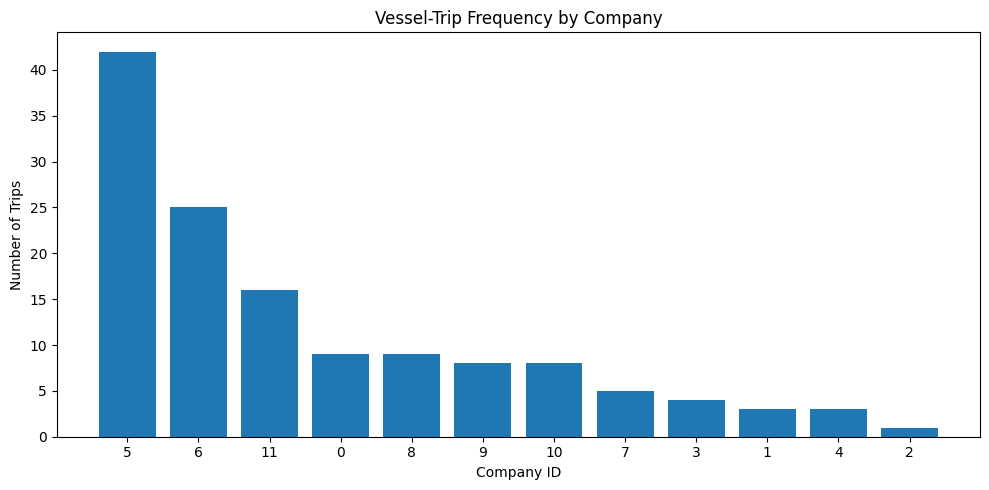

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(company_activity["Company ID"].astype(str), company_activity["Trips"])
plt.title("Vessel-Trip Frequency by Company")
plt.xlabel("Company ID")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

### 5.2 Vessel Activity


In [12]:
vessel_activity = (
    vessel_trip_df["Nama Kapal"]
    .value_counts()
    .rename_axis("Vessel ID")
    .reset_index(name="Trips")
)

top5_vessel_share = vessel_activity.head(5)["Trips"].sum() / vessel_activity["Trips"].sum() * 100

print(f"Number of vessels: {len(vessel_activity)}")
print(f"Top 5 vessels' share of vessel-trip records: {top5_vessel_share:.2f}%")
vessel_activity.head(10)

Number of vessels: 26
Top 5 vessels' share of vessel-trip records: 38.35%


,Vessel ID,Trips
0,9,12
1,24,11
2,22,10
3,20,9
4,3,9
5,15,8
6,4,8
7,5,8
8,10,8
9,21,7


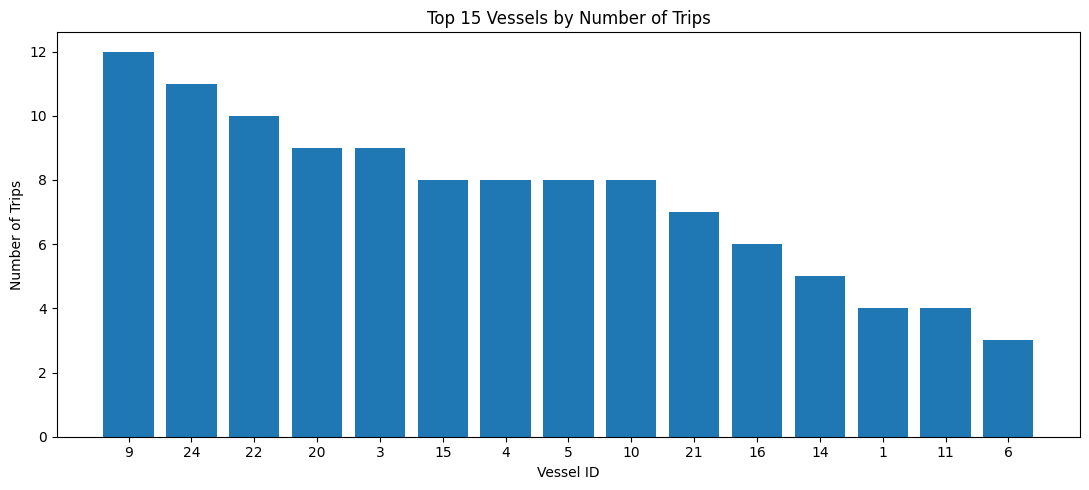

In [13]:
top_vessels = vessel_activity.head(15)

plt.figure(figsize=(11, 5))
plt.bar(top_vessels["Vessel ID"].astype(str), top_vessels["Trips"])
plt.title("Top 15 Vessels by Number of Trips")
plt.xlabel("Vessel ID")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

### 5.3 Vessel Size and PHPP Tariff Group


In [14]:
vessel_trip_df["Tarif Pungutan (%)"] = np.where(
    vessel_trip_df["Ukuran Kapal (GT)"] <= 60,
    "5% (≤60 GT)",
    "10% (>60 GT)"
)

tariff_distribution = vessel_trip_df["Tarif Pungutan (%)"].value_counts()
tariff_distribution

Tarif Pungutan (%)
10% (>60 GT)    125
5% (≤60 GT)       8
Name: count, dtype: int64

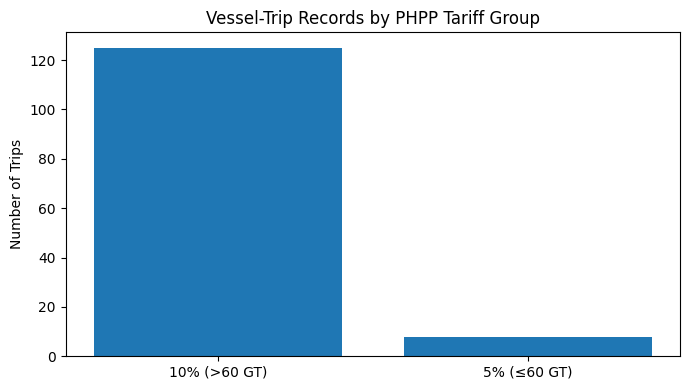

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(tariff_distribution.index, tariff_distribution.values)
plt.title("Vessel-Trip Records by PHPP Tariff Group")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

### 5.4 Fishing Gear Distribution

The encoded fishing-gear categories are mapped back to their operational labels for interpretability.


In [16]:
gear_mapping = {
    0: "Pukat Cincin Pelagis Besar",
    1: "Pukat Cincin Pelagis Kecil",
    2: "Rawai Tuna"
}

vessel_trip_df["Fishing Gear"] = vessel_trip_df["Alat Penangkapan Ikan"].map(gear_mapping)

gear_distribution = (
    vessel_trip_df["Fishing Gear"]
    .value_counts()
    .rename_axis("Fishing Gear")
    .reset_index(name="Trips")
)

gear_distribution["Share (%)"] = (
    gear_distribution["Trips"] / gear_distribution["Trips"].sum() * 100
)

gear_distribution

,Fishing Gear,Trips,Share (%)
0,Pukat Cincin Pelagis Besar,68,51.13
1,Pukat Cincin Pelagis Kecil,47,35.34
2,Rawai Tuna,18,13.53


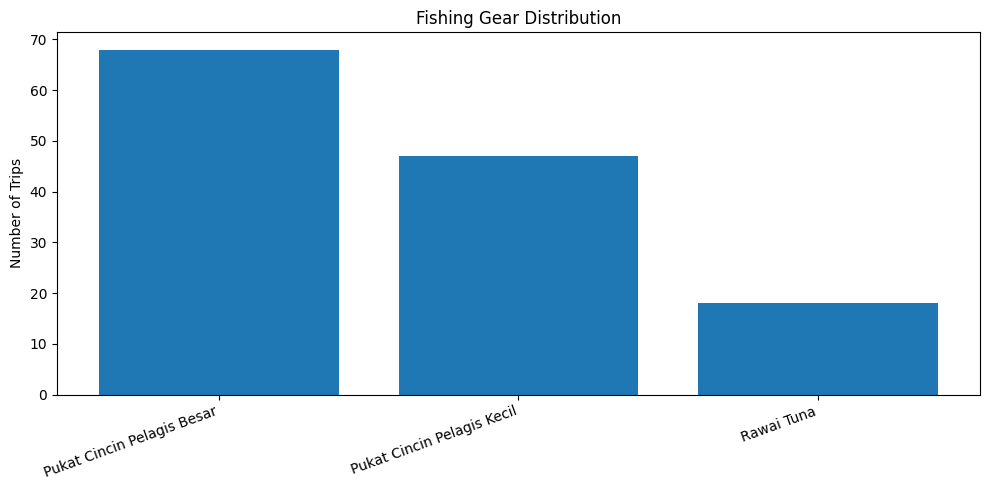

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(gear_distribution["Fishing Gear"], gear_distribution["Trips"])
plt.title("Fishing Gear Distribution")
plt.ylabel("Number of Trips")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Temporal Activity

Departure and arrival records are summarized monthly to identify periods with higher operational activity.

The analysis is descriptive; it does not infer causality or seasonality drivers outside the observed company records.


In [18]:
vessel_trip_df["Departure Month"] = vessel_trip_df["Tanggal Keberangkatan"].dt.to_period("M")
vessel_trip_df["Arrival Month"] = vessel_trip_df["Tanggal Kedatangan"].dt.to_period("M")

departure_monthly = vessel_trip_df.groupby("Departure Month").size()
arrival_monthly = vessel_trip_df.groupby("Arrival Month").size()

display(pd.DataFrame({
    "departures": departure_monthly,
    "arrivals": arrival_monthly
}).fillna(0))

,departures,arrivals
2023-05,1,0.00
2023-06,1,0.00
2023-08,1,0.00
2023-09,1,0.00
2023-10,2,0.00
2023-12,7,0.00
2024-01,3,9.00
2024-02,7,2.00
2024-03,3,9.00
2024-04,23,5.00


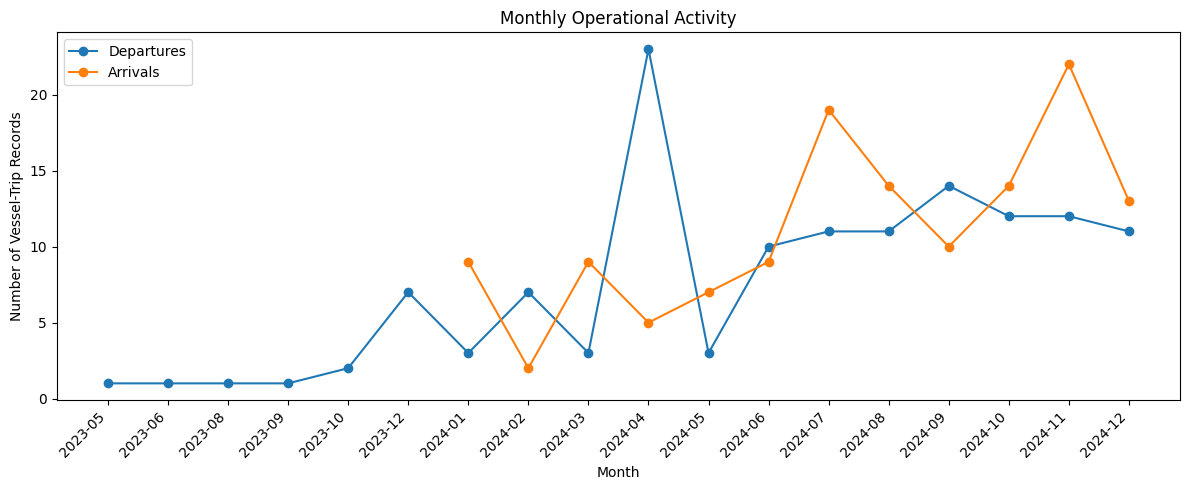

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(departure_monthly.index.astype(str), departure_monthly.values, marker="o", label="Departures")
plt.plot(arrival_monthly.index.astype(str), arrival_monthly.values, marker="o", label="Arrivals")
plt.title("Monthly Operational Activity")
plt.xlabel("Month")
plt.ylabel("Number of Vessel-Trip Records")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Relationships Between Vessel-Trip Variables

Spearman correlation is used for continuous/count variables because several operational variables are skewed and contain valid high-value observations.

Nominal encoded IDs are deliberately excluded from this matrix.


In [20]:
vessel_corr = vessel_trip_df[vessel_numeric].corr(method="spearman")
vessel_corr

,Ukuran Kapal (GT),Besar Pungutan Hasil Perikanan,Jumlah Jenis Ikan,Total Estimasi Nakhoda (kg),Total Volume Ril (kg),Total Nilai Produksi (Rp)
Ukuran Kapal (GT),1.00,0.67,0.28,0.69,0.67,0.67
Besar Pungutan Hasil Perikanan,0.67,1.00,0.46,0.97,1.00,1.00
Jumlah Jenis Ikan,0.28,0.46,1.00,0.40,0.44,0.46
Total Estimasi Nakhoda (kg),0.69,0.97,0.40,1.00,0.97,0.97
Total Volume Ril (kg),0.67,1.00,0.44,0.97,1.00,1.00
Total Nilai Produksi (Rp),0.67,1.00,0.46,0.97,1.00,1.00


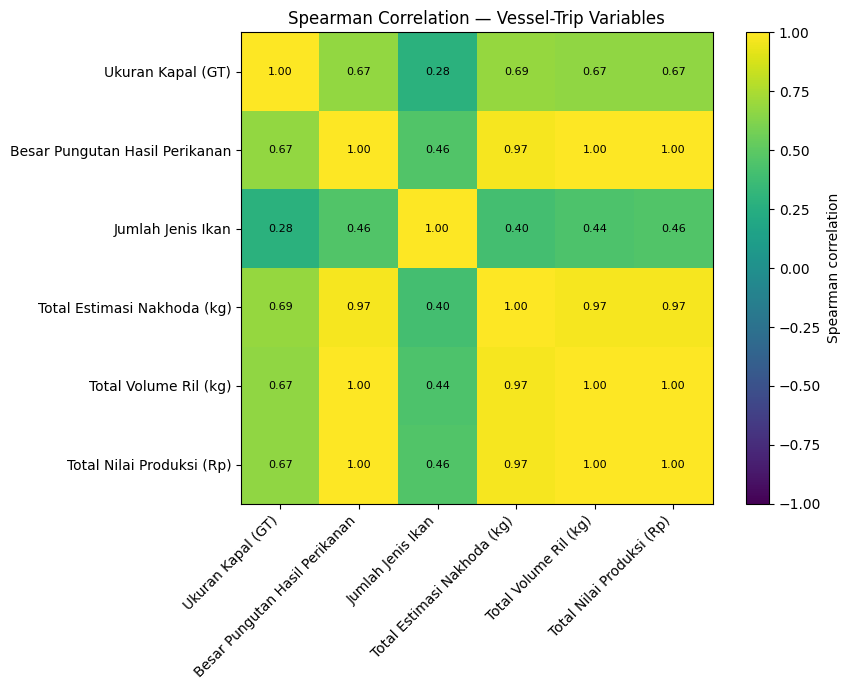

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(vessel_corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(vessel_corr.columns)))
ax.set_xticklabels(vessel_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(vessel_corr.index)))
ax.set_yticklabels(vessel_corr.index)

for i in range(len(vessel_corr.index)):
    for j in range(len(vessel_corr.columns)):
        ax.text(j, i, f"{vessel_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Spearman Correlation — Vessel-Trip Variables")
plt.tight_layout()
plt.show()

### 7.1 Captain Estimate vs. Actual Catch Volume

A simple linear regression is used here as a **descriptive relationship model**, not as a causal or inferential model.

In the original analysis, the vessel-trip relationship was very strong, with approximately:

- **Slope:** 1.10
- **R²:** 0.947

This indicates that total captain estimates and recorded actual catch volumes move closely together at the vessel-trip level.


In [22]:
X_vessel = vessel_trip_df[["Total Estimasi Nakhoda (kg)"]]
y_vessel = vessel_trip_df["Total Volume Ril (kg)"]

vessel_reg = LinearRegression()
vessel_reg.fit(X_vessel, y_vessel)
vessel_pred = vessel_reg.predict(X_vessel)

print(f"Intercept: {vessel_reg.intercept_:,.2f}")
print(f"Slope: {vessel_reg.coef_[0]:.4f}")
print(f"R-squared: {vessel_reg.score(X_vessel, y_vessel):.4f}")

Intercept: -1,040.50
Slope: 1.1002
R-squared: 0.9468


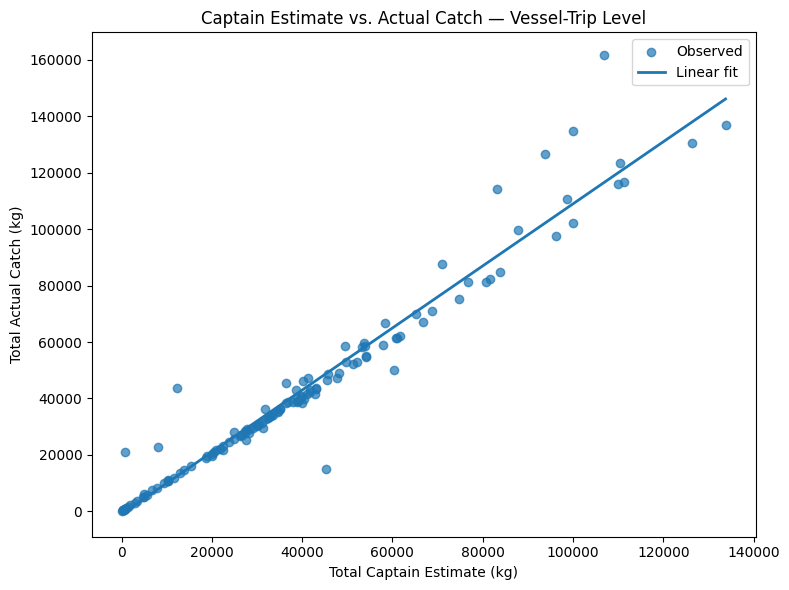

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(X_vessel.iloc[:, 0], y_vessel, alpha=0.7, label="Observed")
order = np.argsort(X_vessel.iloc[:, 0].values)
plt.plot(
    X_vessel.iloc[:, 0].values[order],
    vessel_pred[order],
    linewidth=2,
    label="Linear fit"
)
plt.title("Captain Estimate vs. Actual Catch — Vessel-Trip Level")
plt.xlabel("Total Captain Estimate (kg)")
plt.ylabel("Total Actual Catch (kg)")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Production and Levy Concentration

Production contribution is ranked cumulatively to show how much of the recorded production value is concentrated among higher-value vessel trips.


In [24]:
production_rank = vessel_trip_df[
    ["Nama Kapal", "Total Nilai Produksi (Rp)", "Besar Pungutan Hasil Perikanan"]
].copy()

production_rank = production_rank.sort_values("Total Nilai Produksi (Rp)", ascending=False)

production_rank["Production Share (%)"] = (
    production_rank["Total Nilai Produksi (Rp)"]
    / production_rank["Total Nilai Produksi (Rp)"].sum()
    * 100
)

production_rank["Cumulative Production Share (%)"] = production_rank["Production Share (%)"].cumsum()

production_rank.head(15)

,Nama Kapal,Total Nilai Produksi (Rp),Besar Pungutan Hasil Perikanan,Production Share (%),Cumulative Production Share (%)
72,4,1820978500,182097850,3.18,3.18
96,14,1387891500,138789150,2.42,5.60
81,15,1374987500,137498750,2.40,8.00
92,11,1334341000,133434100,2.33,10.33
74,4,1289742500,128974250,2.25,12.59
75,4,1229528500,122952850,2.15,14.73
109,12,1210159000,121015900,2.11,16.85
91,8,1204393500,120439350,2.10,18.95
80,15,1199955500,119995550,2.10,21.05
83,15,1164547000,116454700,2.03,23.08


## 8. Vessel-Trip Segmentation with K-Means

The clustering stage groups vessel trips by **economic and catch scale**, using:

- Total actual catch volume
- PHPP levy amount
- Total production value

`RobustScaler` is used because the variables contain large, valid operational observations.

> The cluster labels describe **scale**, not efficiency, profitability, or operational quality.


In [25]:
vessel_cluster_features = [
    "Total Volume Ril (kg)",
    "Besar Pungutan Hasil Perikanan",
    "Total Nilai Produksi (Rp)"
]

vessel_scaler = RobustScaler()
X_vessel_cluster = vessel_scaler.fit_transform(vessel_trip_df[vessel_cluster_features])

vessel_silhouette = {}

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_vessel_cluster)
    vessel_silhouette[k] = silhouette_score(X_vessel_cluster, labels)

pd.Series(vessel_silhouette, name="Silhouette Score")

2   0.67
3   0.53
4   0.58
5   0.56
Name: Silhouette Score, dtype: float64

In [26]:
best_vessel_k = max(vessel_silhouette, key=vessel_silhouette.get)

vessel_kmeans = KMeans(n_clusters=best_vessel_k, random_state=42, n_init=10)
vessel_trip_df["Vessel Cluster"] = vessel_kmeans.fit_predict(X_vessel_cluster)

vessel_cluster_summary = vessel_trip_df.groupby("Vessel Cluster")[vessel_cluster_features].agg(
    ["count", "mean", "median"]
)

vessel_cluster_summary

Total Volume Ril (kg)                       \
                               count       mean    median   
Vessel Cluster                                              
0                                110  29,017.46 29,835.00   
1                                 23 101,685.91 99,755.00   

               Besar Pungutan Hasil Perikanan                                \
                                        count           mean         median   
Vessel Cluster                                                                
0                                         110  30,085,601.32  31,349,675.00   
1                                          23 104,557,450.00 100,615,100.00   

               Total Nilai Produksi (Rp)                                    
                                   count             mean           median  
Vessel Cluster                                                              
0                                    110   301,967,160.91   313,496,750.00  
1                                     23 1,045,574,500.00 1,006,151,000.00

In [27]:
cluster_scale_order = (
    vessel_trip_df.groupby("Vessel Cluster")["Total Nilai Produksi (Rp)"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

if len(cluster_scale_order) == 2:
    vessel_cluster_labels = {
        cluster_scale_order[0]: "Lower Economic Scale",
        cluster_scale_order[1]: "Higher Economic Scale"
    }
else:
    vessel_cluster_labels = {
        cluster_id: f"Economic Scale {rank + 1}"
        for rank, cluster_id in enumerate(cluster_scale_order)
    }

vessel_trip_df["Vessel Segment"] = vessel_trip_df["Vessel Cluster"].map(vessel_cluster_labels)

vessel_trip_df["Vessel Segment"].value_counts()

Vessel Segment
Lower Economic Scale     110
Higher Economic Scale     23
Name: count, dtype: int64

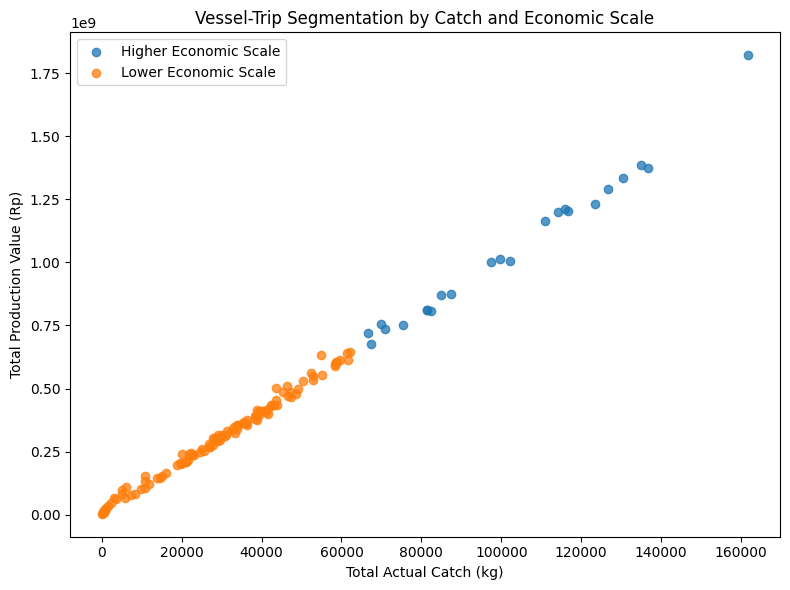

In [28]:
plt.figure(figsize=(8, 6))

for segment, subset in vessel_trip_df.groupby("Vessel Segment"):
    plt.scatter(
        subset["Total Volume Ril (kg)"],
        subset["Total Nilai Produksi (Rp)"],
        alpha=0.75,
        label=segment
    )

plt.title("Vessel-Trip Segmentation by Catch and Economic Scale")
plt.xlabel("Total Actual Catch (kg)")
plt.ylabel("Total Production Value (Rp)")
plt.legend()
plt.tight_layout()
plt.show()

# Part B — Species-Level Analysis


## 9. Species-Level Overview

This section preserves the original 777 fish-species records and evaluates catch quantity, reference price, production value, and species composition.


In [ ]:
species_numeric = [
    "Estimasi Nakhoda (kg)",
    "Volume Ril (kg)",
    "Harga Acuan Ikan per Kg (Rp)",
    "Nilai Produksi (Rp)"
]

species_df[species_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
Estimasi Nakhoda (kg),777.00,"6,631.38","16,673.70",5.00,200.00,625.00,"2,248.00","115,000.00"
Volume Ril (kg),777.00,"7,118.01","17,763.77",8.00,231.00,742.00,"2,558.00","127,783.00"
Harga Acuan Ikan per Kg (Rp),777.00,"14,330.37","6,313.19","7,000.00","9,500.00","9,500.00","22,000.00","28,000.00"
Nilai Produksi (Rp),777.00,"73,699,615.44","168,464,138.08","147,000.00","2,794,000.00","9,786,000.00","46,442,000.00","1,213,938,500.00"


### 9.1 Species-Level Distribution Diagnostics


In [30]:
species_distribution = iqr_diagnostic(species_df, species_numeric)
species_distribution

,variable,skewness,kurtosis,iqr_outliers
0,Estimasi Nakhoda (kg),3.54,13.61,124
1,Volume Ril (kg),3.71,15.39,130
2,Harga Acuan Ikan per Kg (Rp),0.30,-1.62,0
3,Nilai Produksi (Rp),3.64,15.01,116


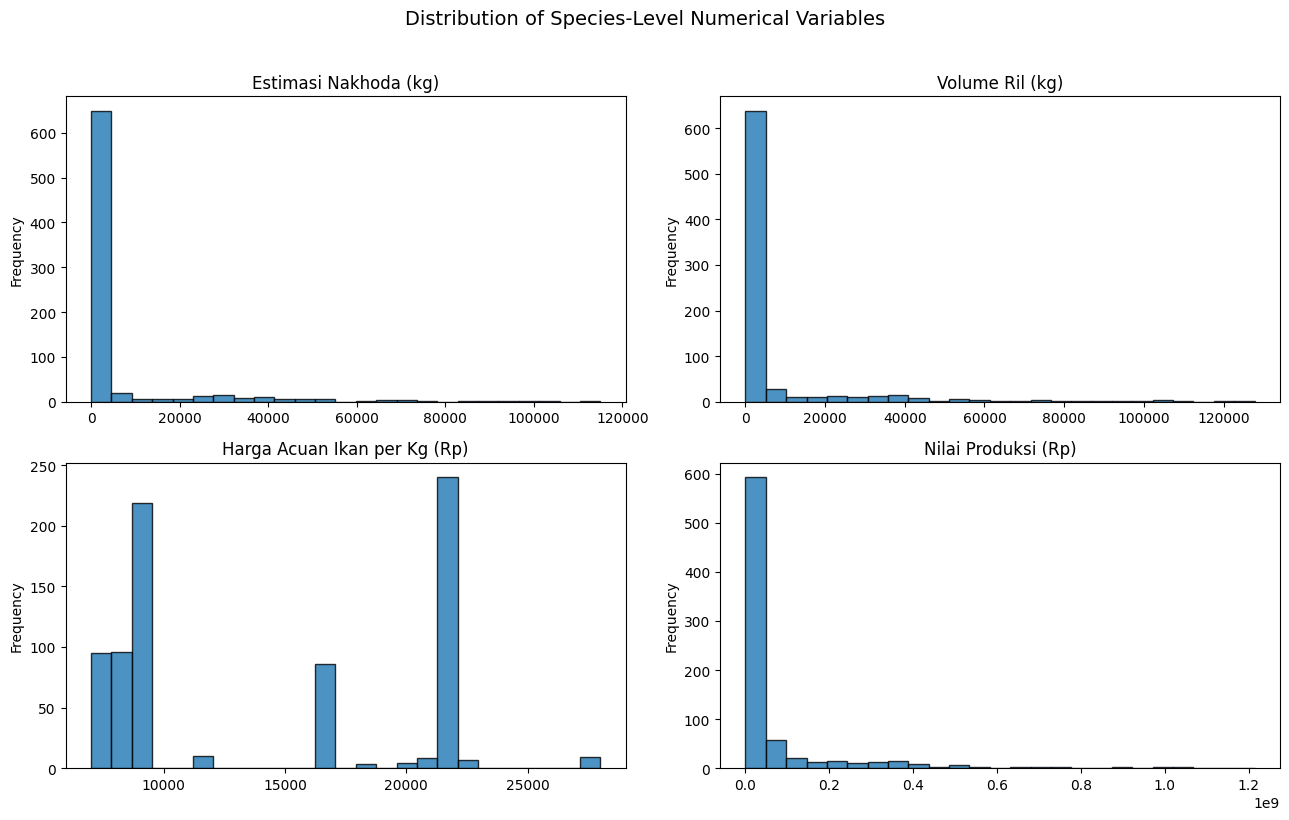

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, column in zip(axes, species_numeric):
    ax.hist(species_df[column].dropna(), bins=25, edgecolor="black", alpha=0.8)
    ax.set_title(column)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Species-Level Numerical Variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 10. Species Composition

The encoded fish-species IDs are mapped to their names using the same mapping used in the original project notebook.


In [32]:
fish_mapping = {
    0: "Albakora (Thunnus Alalunga)",
    1: "Bawal Hitam (Parastromateus Niger)",
    2: "Bawal Sabit (Taractichthys Steindachneri)",
    3: "Cakalang (Katsuwonus Pelamis)",
    4: "Gindara Setan (Ruvettus Pretiosus)",
    5: "Hiu Air (Scoliodon Laticaudus)",
    6: "Ikan Layaran (Istiophorus Platypterus)",
    7: "Ikan Pedang (Xiphias Gladius)",
    8: "Ikan Setan (Lepidocybium Flavobrunneum)",
    9: "Layang Deles (Decapterus Macrosoma)",
    10: "Lemadang (Coryphaena Hippurus)",
    11: "Madidihang (Thunnus Albacares)",
    12: "Semar (Lampris Guttatus)",
    13: "Semar (Mene Maculata)",
    14: "Setuhuk Hitam (Istiompax Indica; Makaira Indica)",
    15: "Setuhuk Loreng (Tetrapturus Audax)",
    16: "Sunglir (Elagatis Bipinnulata)",
    17: "Tenggiri (Scomberomorus Commerson)",
    18: "Tongkol Abu-abu (Thunnus Tonggol)",
    19: "Tongkol Banyar (Euthynnus Affinis)",
    20: "Tongkol Pisang-Balaki (Auxis Thazard)",
    21: "Tuna Mata Besar (Thunnus Obesus)",
    22: "Tuna Sirip Biru Selatan (Thunnus Maccoyii)",
    23: "Layang (Decapterus Maruadsi)"
}

species_df["Fish Species"] = species_df["Jenis Ikan"].map(fish_mapping)

species_frequency = (
    species_df["Fish Species"]
    .value_counts()
    .rename_axis("Fish Species")
    .reset_index(name="Records")
)

species_frequency.head(10)

,Fish Species,Records
0,Madidihang (Thunnus Albacares),121
1,Cakalang (Katsuwonus Pelamis),119
2,Tuna Mata Besar (Thunnus Obesus),105
3,Layang Deles (Decapterus Macrosoma),99
4,Sunglir (Elagatis Bipinnulata),93
5,Lemadang (Coryphaena Hippurus),84
6,Tongkol Abu-abu (Thunnus Tonggol),50
7,Tongkol Banyar (Euthynnus Affinis),45
8,Tenggiri (Scomberomorus Commerson),14
9,Tuna Sirip Biru Selatan (Thunnus Maccoyii),9


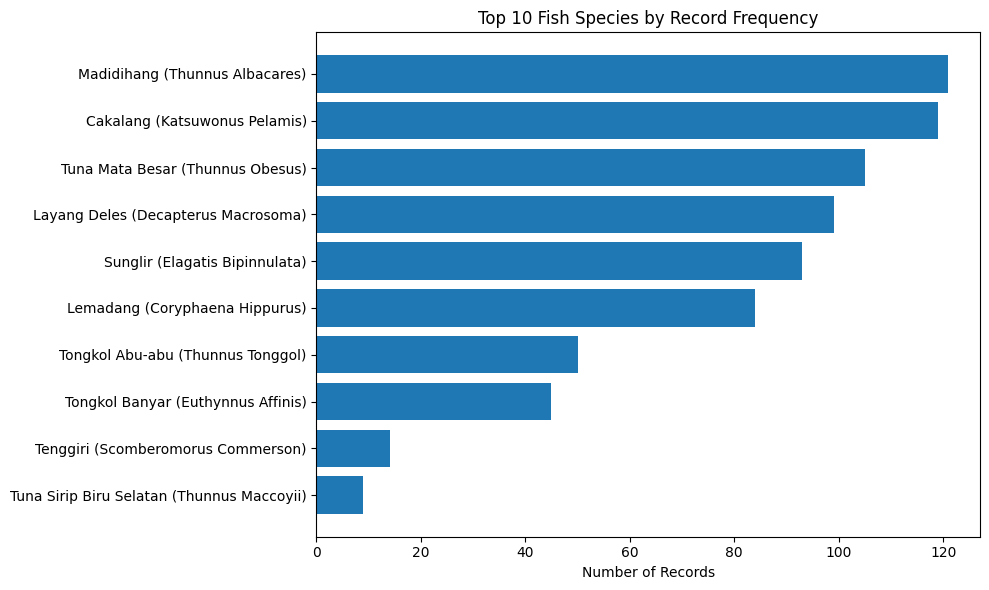

In [33]:
top_species = species_frequency.head(10).sort_values("Records")

plt.figure(figsize=(10, 6))
plt.barh(top_species["Fish Species"], top_species["Records"])
plt.title("Top 10 Fish Species by Record Frequency")
plt.xlabel("Number of Records")
plt.tight_layout()
plt.show()

### 10.1 Total Actual Catch by Species


In [34]:
species_volume = (
    species_df.groupby("Fish Species", as_index=False)["Volume Ril (kg)"]
    .sum()
    .sort_values("Volume Ril (kg)", ascending=False)
)

species_volume.head(10)

,Fish Species,Volume Ril (kg)
3,Cakalang (Katsuwonus Pelamis),4751441
12,Madidihang (Thunnus Albacares),273214
20,Tongkol Banyar (Euthynnus Affinis),141728
10,Layang Deles (Decapterus Macrosoma),98926
22,Tuna Mata Besar (Thunnus Obesus),98437
19,Tongkol Abu-abu (Thunnus Tonggol),88237
17,Sunglir (Elagatis Bipinnulata),34564
11,Lemadang (Coryphaena Hippurus),19800
15,Setuhuk Hitam (Istiompax Indica; Makaira Indica),7491
0,Albakora (Thunnus Alalunga),5089


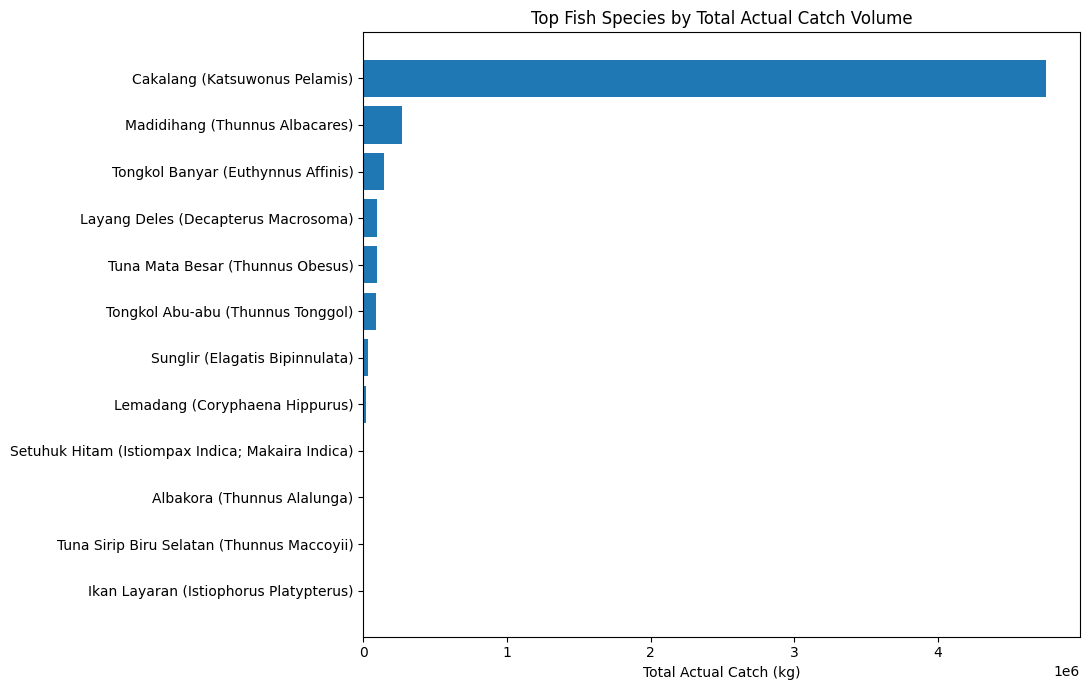

In [35]:
top_species_volume = species_volume.head(12).sort_values("Volume Ril (kg)")

plt.figure(figsize=(11, 7))
plt.barh(top_species_volume["Fish Species"], top_species_volume["Volume Ril (kg)"])
plt.title("Top Fish Species by Total Actual Catch Volume")
plt.xlabel("Total Actual Catch (kg)")
plt.tight_layout()
plt.show()

## 11. Relationships Between Species-Level Variables

As in the vessel-trip section, the correlation matrix includes only genuine numerical measurements. Encoded species and fishing-gear identifiers are excluded.


In [36]:
species_corr = species_df[species_numeric].corr(method="spearman")
species_corr

,Estimasi Nakhoda (kg),Volume Ril (kg),Harga Acuan Ikan per Kg (Rp),Nilai Produksi (Rp)
Estimasi Nakhoda (kg),1.00,0.96,-0.06,0.93
Volume Ril (kg),0.96,1.00,-0.06,0.97
Harga Acuan Ikan per Kg (Rp),-0.06,-0.06,1.00,0.17
Nilai Produksi (Rp),0.93,0.97,0.17,1.00


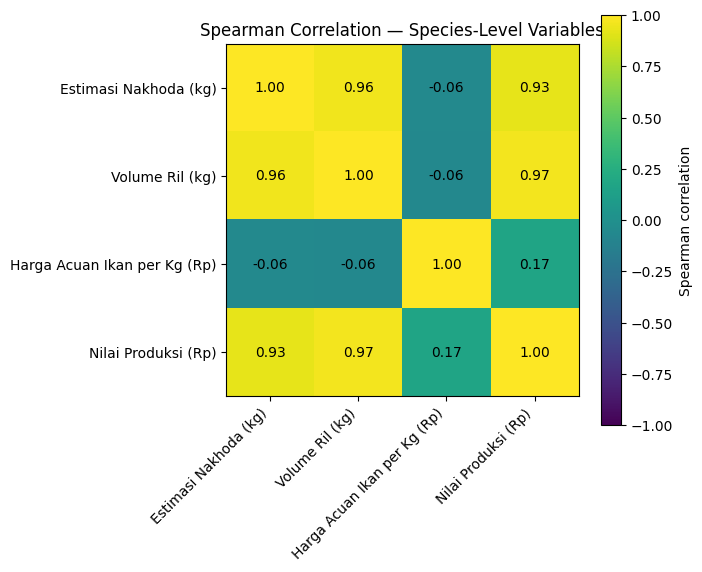

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(species_corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(species_corr.columns)))
ax.set_xticklabels(species_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(species_corr.index)))
ax.set_yticklabels(species_corr.index)

for i in range(len(species_corr.index)):
    for j in range(len(species_corr.columns)):
        ax.text(j, i, f"{species_corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Spearman Correlation — Species-Level Variables")
plt.tight_layout()
plt.show()

### 11.1 Captain Estimate vs. Actual Catch Volume

At species level, the original analysis showed an even tighter descriptive linear relationship:

- **Slope:** approximately 1.05
- **R²:** approximately 0.978

This suggests that captain estimates track recorded actual catch volume closely across individual species records.


In [38]:
X_species = species_df[["Estimasi Nakhoda (kg)"]]
y_species = species_df["Volume Ril (kg)"]

species_reg = LinearRegression()
species_reg.fit(X_species, y_species)
species_pred = species_reg.predict(X_species)

print(f"Intercept: {species_reg.intercept_:,.2f}")
print(f"Slope: {species_reg.coef_[0]:.4f}")
print(f"R-squared: {species_reg.score(X_species, y_species):.4f}")

Intercept: 131.87
Slope: 1.0535
R-squared: 0.9778


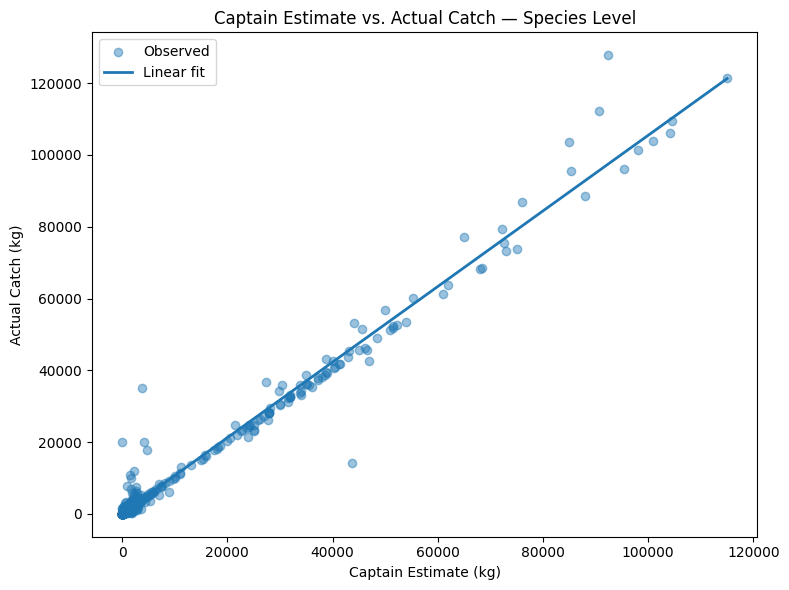

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(X_species.iloc[:, 0], y_species, alpha=0.45, label="Observed")
order = np.argsort(X_species.iloc[:, 0].values)
plt.plot(
    X_species.iloc[:, 0].values[order],
    species_pred[order],
    linewidth=2,
    label="Linear fit"
)
plt.title("Captain Estimate vs. Actual Catch — Species Level")
plt.xlabel("Captain Estimate (kg)")
plt.ylabel("Actual Catch (kg)")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Species Catch-Scale Segmentation with K-Means

The final species clustering uses only:

- Captain-estimated catch volume
- Recorded actual catch volume

These variables are scaled with `RobustScaler`. The cluster labels represent **catch-volume magnitude**, not biological rarity, seasonality, commercial value, or conservation status.


In [40]:
species_cluster_features = [
    "Estimasi Nakhoda (kg)",
    "Volume Ril (kg)"
]

species_scaler = RobustScaler()
X_species_cluster = species_scaler.fit_transform(species_df[species_cluster_features])

species_silhouette = {}

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_species_cluster)
    species_silhouette[k] = silhouette_score(X_species_cluster, labels)

pd.Series(species_silhouette, name="Silhouette Score")

2   0.88
3   0.89
4   0.88
5   0.87
Name: Silhouette Score, dtype: float64

In [41]:
best_species_k = max(species_silhouette, key=species_silhouette.get)

species_kmeans = KMeans(n_clusters=best_species_k, random_state=42, n_init=10)
species_df["Species Cluster"] = species_kmeans.fit_predict(X_species_cluster)

species_cluster_summary = species_df.groupby("Species Cluster")[species_cluster_features].agg(
    ["count", "mean", "median", "min", "max"]
)

species_cluster_summary

Estimasi Nakhoda (kg)                                     \
                                count      mean    median    min     max   
Species Cluster                                                            
0                                 681  1,224.47    500.00      5   17550   
1                                  21 83,455.57 84,990.00  61000  115000   
2                                  75 34,215.37 33,780.00  18000   55200   

                Volume Ril (kg)                                     
                          count      mean    median    min     max  
Species Cluster                                                     
0                           681  1,515.22    542.00      8   35069  
1                            21 90,149.33 88,482.00  61277  127783  
2                            75 34,742.57 34,133.00  14278   60152

In [42]:
species_cluster_order = (
    species_df.groupby("Species Cluster")["Volume Ril (kg)"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

volume_labels = ["Low Catch Volume", "Medium Catch Volume", "High Catch Volume"]

species_cluster_labels = {
    cluster_id: volume_labels[rank]
    if rank < len(volume_labels)
    else f"Catch Volume Segment {rank + 1}"
    for rank, cluster_id in enumerate(species_cluster_order)
}

species_df["Catch Volume Segment"] = species_df["Species Cluster"].map(species_cluster_labels)

species_df["Catch Volume Segment"].value_counts()

Catch Volume Segment
Low Catch Volume       681
Medium Catch Volume     75
High Catch Volume       21
Name: count, dtype: int64

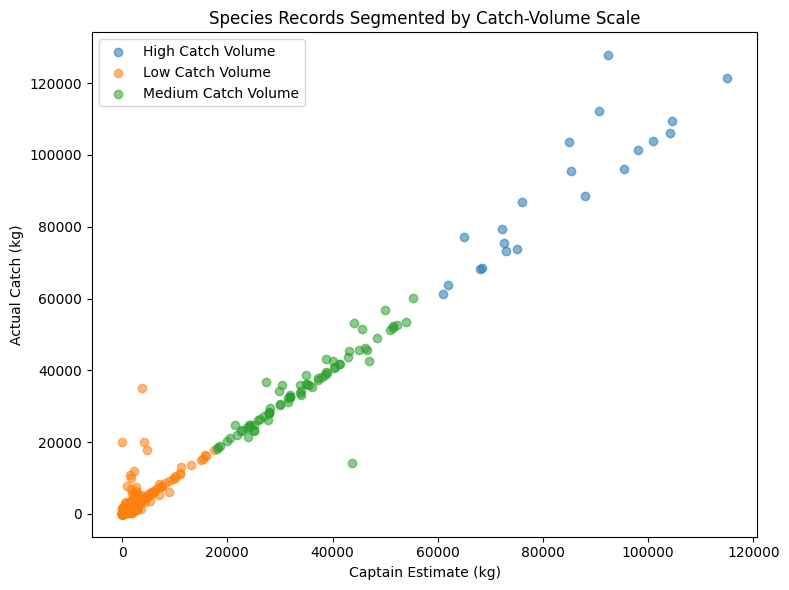

In [43]:
plt.figure(figsize=(8, 6))

for segment, subset in species_df.groupby("Catch Volume Segment"):
    plt.scatter(
        subset["Estimasi Nakhoda (kg)"],
        subset["Volume Ril (kg)"],
        alpha=0.55,
        label=segment
    )

plt.title("Species Records Segmented by Catch-Volume Scale")
plt.xlabel("Captain Estimate (kg)")
plt.ylabel("Actual Catch (kg)")
plt.legend()
plt.tight_layout()
plt.show()

# 13. Key Findings

The original analytical results provide several portfolio-relevant findings:

- The **777 species-level records** consolidate into **133 vessel-trip records**.
- The data cover **12 companies**, **26 vessels**, **3 fishing-gear categories**, and **24 fish species**.
- The three most active company IDs account for approximately **62.41%** of vessel-trip records, indicating a concentrated operational client/activity structure.
- **Pukat Cincin Pelagis Besar** is the most frequently recorded fishing gear at the vessel-trip level.
- Captain-estimated catch and actual catch are strongly aligned at both analytical grains:
  - Vessel-trip level: **R² ≈ 0.947**
  - Species-record level: **R² ≈ 0.978**
- The vessel-trip K-Means analysis in the original notebook achieved its best tested silhouette score at **k = 2 (≈ 0.665)** for the selected economic/catch-scale features.
- The species-record segmentation achieved its best tested silhouette score at **k = 3 (≈ 0.894)** using estimated and actual catch volume.

These findings show that the project goes beyond visualization: it combines data-grain design, operational EDA, descriptive modeling, and unsupervised segmentation on real company records.


# 14. Interpretation Boundaries

Several analytical boundaries are important when reading the results:

1. **Encoded identifiers are nominal.** Company, vessel, fish-species, and gear codes do not have numeric order.
2. **Outliers are not automatically errors.** High-volume and high-value observations may represent genuine large operations.
3. **Regression is descriptive.** The fitted lines summarize association between estimated and actual catch; they do not establish causality.
4. **K-Means describes scale-based segments.** A higher-volume or higher-value cluster should not automatically be interpreted as more efficient or better performing.
5. **PHPP levy and production value are closely related operational measures.** Clustering results that include both should be interpreted primarily as economic-scale segmentation rather than independent multidimensional performance.


# 15. Analysis Summary

This notebook transforms the preprocessed PHPP records into two analytically appropriate data grains and uses them to examine:

- fleet and company activity;
- vessel and fishing-gear profiles;
- temporal operational patterns;
- catch-estimation accuracy;
- production and levy concentration;
- fish-species composition; and
- K-Means segmentation.

The workflow demonstrates practical handling of real operational data from raw business records through structured exploratory and unsupervised analysis.
